In [1]:
import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# # ACPI Interval Narrowing for Electric Motor Torque Prediction
#
# This notebook demonstrates how to generate counterfactual explanations that:
# 1. Maintain prediction interval coverage (uncertainty quantification)
# 2. Reduce interval width for more precise predictions
# 3. Respect physical constraints of motor operation
#
# **Dataset**: Electric Motor Temperature (predicting torque)
# **Goal**: Optimize motor operating conditions to achieve narrower torque prediction intervals


In [2]:
# Configuration
DATA_PATH = "../data/ElectricMotorTemperature.csv"
TARGET_COL = "torque"  # Match your trained model
ALPHA = 0.1  # 90% prediction intervals
SEED = 42

# Set seeds
np.random.seed(SEED)
torch.manual_seed(SEED)


# ## Load Pre-trained ACPI Model


In [3]:
# ## Define ACPI Wrapper for PyTorch Model

class PyTorchACPIWrapper:
    """ACPI wrapper for PyTorch model."""

    def __init__(self, model, device):
        self.model = model
        self.device = device

    def predict(self, X):
        """Predict using the PyTorch model."""
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.from_numpy(X).float().to(self.device)
            predictions = self.model(X_tensor).cpu().numpy().reshape(-1)
        return predictions

In [4]:
# Load the trained ACPI model (from MotorTempACPI_RF.ipynb)
ACPI_MODEL_PATH = "../models/acpi_motor_torque_model.pkl"

try:
    print(f"Loading ACPI model from {ACPI_MODEL_PATH}...")
    acpi_save_dict = joblib.load(ACPI_MODEL_PATH)

    acpi_model = acpi_save_dict['acpi_model']
    pytorch_wrapper = acpi_save_dict['pytorch_wrapper']
    x_scaler = acpi_save_dict['scaler_x']
    y_scaler = acpi_save_dict['scaler_y']
    feature_names = acpi_save_dict['feature_names']
    target_name = acpi_save_dict['target_name']

    print("✓ Loaded pre-trained ACPI model")
    print(f"  Features: {feature_names}")
    print(f"  Target: {target_name}")

except FileNotFoundError:
    print(f"ERROR: ACPI model not found at {ACPI_MODEL_PATH}")
    print("Please run MotorTempACPI_RF.ipynb first to train and save the model.")
    raise


Loading ACPI model from ../models/acpi_motor_torque_model.pkl...
✓ Loaded pre-trained ACPI model
  Features: ['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth', 'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient']
  Target: torque


# ## Data Loading and Preparation


In [5]:
def load_motor_data(filepath):
    """Load and prepare motor data (matching the training notebook)."""
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)

    # Drop profile_id if present
    if 'profile_id' in df.columns:
        df.drop('profile_id', axis=1, inplace=True)

    print(f"Loaded {len(df)} samples")
    print(f"Columns: {df.columns.tolist()}")

    return df

# Load data
motor_df = load_motor_data(DATA_PATH)

# Split features/target (matching training)
X = motor_df.drop(TARGET_COL, axis=1)
y = motor_df[TARGET_COL]

# Train/test split (same as training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=SEED
)

# Scale using the saved scalers
X_test_scaled = pd.DataFrame(
    x_scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)
y_test_scaled = pd.DataFrame(
    y_scaler.transform(y_test.values.reshape(-1, 1)),
    columns=[TARGET_COL],
    index=y_test.index
)

print(f"\nData shapes:")
print(f"  X_test: {X_test_scaled.shape}")
print(f"  y_test: {y_test_scaled.shape}")

# Split test into calibration and evaluation
cal_size = 0.5
n_cal = int(len(X_test_scaled) * cal_size)

X_cal = X_test_scaled.values[:n_cal]
y_cal = y_test_scaled.values[:n_cal].reshape(-1)

X_eval = X_test_scaled.values[n_cal:]
y_eval = y_test_scaled.values[n_cal:].reshape(-1)

print(f"\nTest split for ACPI:")
print(f"  Calibration: {len(X_cal)} samples")
print(f"  Evaluation:  {len(X_eval)} samples")


Loading data from ../data/ElectricMotorTemperature.csv...
Loaded 1330816 samples
Columns: ['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth', 'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque']

Data shapes:
  X_test: (439170, 11)
  y_test: (439170, 1)

Test split for ACPI:
  Calibration: 219585 samples
  Evaluation:  219585 samples


# ## Define Physical Constraints


In [6]:
def get_motor_constraints(feature_names):
    """Define feasible ranges for motor operating parameters."""
    n_features = len(feature_names)

    # Define per-feature constraints based on motor specifications
    feature_constraints = {
        'ambient': (10, 50),        # Ambient temperature (°C)
        'coolant': (10, 50),        # Coolant temperature (°C)
        'u_d': (-500, 500),         # d-axis voltage
        'u_q': (-500, 500),         # q-axis voltage
        'motor_speed': (-5000, 5000),  # Motor speed (rpm)
        'i_d': (-300, 300),         # d-axis current
        'i_q': (-300, 300),         # q-axis current
        'pm': (20, 200),            # PM temperature (°C)
        'stator_yoke': (20, 150),   # Stator yoke temperature (°C)
        'stator_tooth': (20, 150),  # Stator tooth temperature (°C)
        'stator_winding': (20, 200) # Stator winding temperature (°C)
    }

    # Build bounds arrays
    lower_bounds = np.zeros(n_features)
    upper_bounds = np.zeros(n_features)

    for feat_idx, feat_name in enumerate(feature_names):
        if feat_name in feature_constraints:
            lb, ub = feature_constraints[feat_name]
            lower_bounds[feat_idx] = lb
            upper_bounds[feat_idx] = ub
        else:
            # Default wide bounds
            lower_bounds[feat_idx] = -1e6
            upper_bounds[feat_idx] = 1e6

    # Immutable features: ambient temperature (external condition)
    immutable_features = ['ambient']
    immutable_mask = np.zeros(n_features, dtype=bool)

    for feat_name in immutable_features:
        if feat_name in feature_names:
            feat_idx = feature_names.index(feat_name)
            immutable_mask[feat_idx] = True

    print(f"\nPhysical constraints defined:")
    print(f"  Immutable features: {immutable_features}")
    print(f"  Immutable positions: {np.sum(immutable_mask)} / {n_features}")

    return lower_bounds, upper_bounds, immutable_mask

# Get constraints (in scaled space - will apply to scaled data)
lower_bounds_orig = np.array([-1e6] * len(feature_names))  # Wide bounds for scaled data
upper_bounds_orig = np.array([1e6] * len(feature_names))
immutable_mask = np.zeros(len(feature_names), dtype=bool)

# Mark ambient as immutable
if 'ambient' in feature_names:
    immutable_mask[feature_names.index('ambient')] = True

print(f"\nUsing constraints for scaled features (11 features)")



Using constraints for scaled features (11 features)


# ## Generative VAE for Counterfactual Generation


In [7]:
class MotorCounterfactualGenerator:
    """VAE-based counterfactual generator for motor torque prediction."""

    def __init__(self, prediction_model, device, alpha=0.1, latent_dim=8):
        self.prediction_model = prediction_model
        self.device = device
        self.alpha = alpha
        self.latent_dim = latent_dim
        self.vae = None
        self.is_trained = False

    def _build_vae(self, input_dim):
        """Build VAE architecture."""
        class MotorVAE(nn.Module):
            def __init__(self, input_dim, latent_dim, hidden_dim=64):
                super().__init__()
                self.input_dim = input_dim
                self.latent_dim = latent_dim

                # Encoder
                self.encoder = nn.Sequential(
                    nn.Linear(input_dim, hidden_dim),
                    nn.LayerNorm(hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(hidden_dim, hidden_dim // 2),
                    nn.LayerNorm(hidden_dim // 2),
                    nn.ReLU(),
                )
                self.mu_layer = nn.Linear(hidden_dim // 2, latent_dim)
                self.logvar_layer = nn.Linear(hidden_dim // 2, latent_dim)

                # Decoder
                self.decoder = nn.Sequential(
                    nn.Linear(latent_dim, hidden_dim // 2),
                    nn.LayerNorm(hidden_dim // 2),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(hidden_dim // 2, hidden_dim),
                    nn.LayerNorm(hidden_dim),
                    nn.ReLU(),
                    nn.Linear(hidden_dim, input_dim)
                )

                self.apply(self._init_weights)

            def _init_weights(self, module):
                if isinstance(module, nn.Linear):
                    torch.nn.init.xavier_uniform_(module.weight)
                    if module.bias is not None:
                        torch.nn.init.zeros_(module.bias)

            def encode(self, x):
                h = self.encoder(x)
                mu = self.mu_layer(h)
                logvar = torch.clamp(self.logvar_layer(h), min=-10, max=10)
                return mu, logvar

            def reparameterize(self, mu, logvar):
                std = torch.exp(0.5 * logvar)
                eps = torch.randn_like(std)
                return mu + eps * std

            def decode(self, z):
                return self.decoder(z)

            def forward(self, x):
                mu, logvar = self.encode(x)
                z = self.reparameterize(mu, logvar)
                recon = self.decode(z)
                return recon, mu, logvar, z

        return MotorVAE(input_dim, self.latent_dim).to(self.device)

    def train_vae(self, X_sequences, epochs=200, batch_size=256, lr=1e-3, beta=0.05):
        """Train VAE on motor operating data."""
        print("\nTraining VAE for motor counterfactual generation...")
        X_sequences = np.asarray(X_sequences, dtype=np.float32)

        # Data already scaled
        self.mean_X = np.mean(X_sequences, axis=0, keepdims=True)
        self.std_X = np.std(X_sequences, axis=0, keepdims=True) + 1e-8
        X_normalized = (X_sequences - self.mean_X) / self.std_X

        # Build model
        input_dim = X_sequences.shape[1]
        self.vae = self._build_vae(input_dim)
        optimizer = torch.optim.AdamW(self.vae.parameters(), lr=lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        dataset = TensorDataset(torch.tensor(X_normalized, dtype=torch.float32))
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        self.vae.train()
        for epoch in range(epochs):
            total_loss = 0
            total_recon = 0
            total_kl = 0

            for (batch_x,) in dataloader:
                batch_x = batch_x.to(self.device)
                optimizer.zero_grad()

                recon, mu, logvar, _ = self.vae(batch_x)

                # Reconstruction loss
                recon_loss = nn.functional.mse_loss(recon, batch_x, reduction='mean')

                # KL divergence
                kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

                # Combined loss
                loss = recon_loss + beta * kl_loss

                if torch.isnan(loss):
                    continue

                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.vae.parameters(), max_norm=1.0)
                optimizer.step()

                total_loss += loss.item()
                total_recon += recon_loss.item()
                total_kl += kl_loss.item()

            scheduler.step()

            avg_loss = total_loss / len(dataloader)
            avg_recon = total_recon / len(dataloader)
            avg_kl = total_kl / len(dataloader)

            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | "
                      f"Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}")

        self.vae.eval()
        self.is_trained = True
        print("VAE training completed!")

    def _normalize_input(self, x):
        return (x - self.mean_X) / self.std_X

    def _denormalize_output(self, x_norm):
        return x_norm * self.std_X + self.mean_X

    def generate_narrower_intervals(self, x_orig, y_true, current_lower, current_upper,
                                   n_samples=5000, exploration_std=0.3,
                                   lower_bounds=None, upper_bounds=None,
                                   immutable_mask=None, target_reduction=0.7):
        """Generate counterfactuals for narrower torque prediction intervals."""
        if not self.is_trained:
            raise ValueError("VAE must be trained before generating counterfactuals!")

        x_orig_np = np.asarray(x_orig, dtype=np.float32).flatten()
        x_orig_norm = self._normalize_input(x_orig_np.reshape(1, -1))
        x_orig_t = torch.tensor(x_orig_norm, device=self.device, dtype=torch.float32)

        current_width = current_upper - current_lower
        target_width = current_width * target_reduction

        # Encode original to latent space
        with torch.no_grad():
            mu_orig, _ = self.vae.encode(x_orig_t)
            if torch.isnan(mu_orig).any():
                mu_orig = torch.zeros_like(mu_orig)

        successful_results = []

        for _ in range(n_samples):
            # Sample from latent space
            with torch.no_grad():
                z_sample = mu_orig + exploration_std * torch.randn_like(mu_orig)
                x_cf_norm = self.vae.decode(z_sample).squeeze(0)

            x_cf_denorm = self._denormalize_output(x_cf_norm.cpu().numpy().reshape(1, -1)).flatten()

            # Apply immutability constraints
            if immutable_mask is not None:
                x_cf_denorm[immutable_mask] = x_orig_np[immutable_mask]

            # Get new prediction interval
            x_cf_input = x_cf_denorm.reshape(1, -1)
            y_lower_cf, y_upper_cf = self.prediction_model.predict_pi(x_cf_input, method='qrf')

            new_width = y_upper_cf[0] - y_lower_cf[0]

            # Check: maintains coverage AND narrower interval
            maintains_coverage = (y_lower_cf[0] <= y_true <= y_upper_cf[0])
            is_narrower = new_width < current_width

            if maintains_coverage and is_narrower:
                width_reduction_pct = (current_width - new_width) / current_width * 100

                result = {
                    "x_cf": x_cf_denorm,
                    "original_width": float(current_width),
                    "new_width": float(new_width),
                    "width_reduction": float(current_width - new_width),
                    "width_reduction_pct": float(width_reduction_pct),
                    "original_lower": float(current_lower),
                    "original_upper": float(current_upper),
                    "new_lower": float(y_lower_cf[0]),
                    "new_upper": float(y_upper_cf[0]),
                    "y_true": float(y_true),
                    "l1_distance": float(np.abs(x_cf_denorm - x_orig_np).sum()),
                    "l2_distance": float(np.linalg.norm(x_cf_denorm - x_orig_np)),
                }
                successful_results.append(result)

        if not successful_results:
            return {"status": "no_improvement", "n_successful": 0, "results": []}

        # Sort by width reduction
        successful_results.sort(key=lambda x: x["width_reduction"], reverse=True)

        return {
            "status": "success",
            "n_successful": len(successful_results),
            "results": successful_results,
            "x_orig": x_orig_np,
            "y_true": float(y_true),
            "original_interval": [float(current_lower), float(current_upper)]
        }


In [8]:
import os

# Initialize and train generator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

generator = MotorCounterfactualGenerator(
    prediction_model=acpi_model,
    device=device,
    alpha=ALPHA,
    latent_dim=8
)

# Use training data for VAE (scaled)
X_train_scaled = x_scaler.transform(X_train)

# Train VAE
generator.train_vae(X_train_scaled, epochs=200, batch_size=256, lr=1e-3, beta=0.05)



Using device: cpu

Training VAE for motor counterfactual generation...
Epoch 5/200 | Loss: 0.1087 | Recon: 0.0507 | KL: 1.1611
Epoch 10/200 | Loss: 0.0997 | Recon: 0.0426 | KL: 1.1435
Epoch 15/200 | Loss: 0.0920 | Recon: 0.0368 | KL: 1.1041
Epoch 20/200 | Loss: 0.0901 | Recon: 0.0349 | KL: 1.1041
Epoch 25/200 | Loss: 0.0889 | Recon: 0.0336 | KL: 1.1053
Epoch 30/200 | Loss: 0.0881 | Recon: 0.0327 | KL: 1.1071
Epoch 35/200 | Loss: 0.0872 | Recon: 0.0318 | KL: 1.1085
Epoch 40/200 | Loss: 0.0869 | Recon: 0.0314 | KL: 1.1086
Epoch 45/200 | Loss: 0.0865 | Recon: 0.0311 | KL: 1.1087
Epoch 50/200 | Loss: 0.0862 | Recon: 0.0308 | KL: 1.1084
Epoch 55/200 | Loss: 0.0860 | Recon: 0.0305 | KL: 1.1084
Epoch 60/200 | Loss: 0.0858 | Recon: 0.0304 | KL: 1.1084
Epoch 65/200 | Loss: 0.0856 | Recon: 0.0301 | KL: 1.1085
Epoch 70/200 | Loss: 0.0854 | Recon: 0.0300 | KL: 1.1084
Epoch 75/200 | Loss: 0.0852 | Recon: 0.0298 | KL: 1.1081
Epoch 80/200 | Loss: 0.0850 | Recon: 0.0296 | KL: 1.1078
Epoch 85/200 | Lo

# ## Single Instance Optimization Demo


In [9]:
# Get baseline predictions
y_lower_baseline, y_upper_baseline = acpi_model.predict_pi(X_eval, method='qrf')
baseline_coverage = float(np.mean((y_eval >= y_lower_baseline) & (y_eval <= y_upper_baseline)))
baseline_width = float(np.mean(y_upper_baseline - y_lower_baseline))

print(f"\nBaseline Performance:")
print(f"  Coverage: {baseline_coverage:.4f} (target: {1-ALPHA:.4f})")
print(f"  Mean interval width: {baseline_width:.4f} (scaled units)")

# Select instance with wide interval
covered_mask = (y_eval >= y_lower_baseline) & (y_eval <= y_upper_baseline)
covered_idx = np.where(covered_mask)[0]
widths = y_upper_baseline - y_lower_baseline
covered_widths = widths[covered_idx]

# Pick instance with width above 75th percentile
width_75 = np.percentile(widths, 75)
wide_idx = covered_idx[covered_widths > width_75]

if len(wide_idx) > 0:
    demo_idx = np.random.choice(wide_idx)

    x_demo = X_eval[demo_idx]
    y_demo = y_eval[demo_idx]
    lower_demo = y_lower_baseline[demo_idx]
    upper_demo = y_upper_baseline[demo_idx]
    width_demo = upper_demo - lower_demo

    print(f"\n{'='*70}")
    print(f"SINGLE INSTANCE OPTIMIZATION DEMO")
    print(f"{'='*70}")
    print(f"\nSelected instance {demo_idx}:")
    print(f"  True torque: {y_demo:.4f} (scaled)")
    print(f"  Current interval: [{lower_demo:.4f}, {upper_demo:.4f}]")
    print(f"  Current width: {width_demo:.4f}")

    # Generate optimized operating conditions
    print(f"\nGenerating optimized motor operating conditions...")
    result = generator.generate_narrower_intervals(
        x_demo, y_demo, lower_demo, upper_demo,
        n_samples=5000,
        exploration_std=0.3,
        lower_bounds=lower_bounds_orig,
        upper_bounds=upper_bounds_orig,
        immutable_mask=immutable_mask,
        target_reduction=0.6
    )

    print(f"\nOptimization result: {result['status']}")
    print(f"Successful candidates: {result.get('n_successful', 0)}")

    if result['status'] == 'success' and result['n_successful'] > 0:
        best = result['results'][0]
        print(f"\n{'='*70}")
        print(f"BEST OPTIMIZATION FOUND")
        print(f"{'='*70}")
        print(f"  New interval: [{best['new_lower']:.4f}, {best['new_upper']:.4f}]")
        print(f"  New width: {best['new_width']:.4f}")
        print(f"  Width reduction: {best['width_reduction']:.4f} ({best['width_reduction_pct']:.1f}%)")
        print(f"  L1 change: {best['l1_distance']:.4f}")
        print(f"  Still covers true value: {best['new_lower']:.4f} ≤ {y_demo:.4f} ≤ {best['new_upper']:.4f}")

        # Show feature changes
        print(f"\n  Feature changes (scaled):")
        for i, fname in enumerate(feature_names):
            orig_val = result['x_orig'][i]
            new_val = best['x_cf'][i]
            change = new_val - orig_val
            if abs(change) > 0.01:
                print(f"    {fname}: {orig_val:.3f} → {new_val:.3f} (Δ{change:+.3f})")



Baseline Performance:
  Coverage: 0.9064 (target: 0.9000)
  Mean interval width: 0.1825 (scaled units)

SINGLE INSTANCE OPTIMIZATION DEMO

Selected instance 87361:
  True torque: 1.4020 (scaled)
  Current interval: [0.7480, 1.4029]
  Current width: 0.6549

Generating optimized motor operating conditions...

Optimization result: success
Successful candidates: 3

BEST OPTIMIZATION FOUND
  New interval: [0.7486, 1.4023]
  New width: 0.6537
  Width reduction: 0.0011 (0.2%)
  L1 change: 4.4684
  Still covers true value: 0.7486 ≤ 1.4020 ≤ 1.4023

  Feature changes (scaled):
    u_q: -0.525 → -0.221 (Δ+0.303)
    coolant: -0.803 → -0.931 (Δ-0.129)
    stator_winding: -0.279 → 0.290 (Δ+0.569)
    u_d: -0.247 → -0.706 (Δ-0.459)
    stator_tooth: -0.533 → 0.074 (Δ+0.607)
    motor_speed: -0.781 → -0.503 (Δ+0.278)
    i_d: 0.043 → -0.026 (Δ-0.069)
    i_q: 1.471 → 1.482 (Δ+0.011)
    pm: -0.814 → 0.816 (Δ+1.630)
    stator_yoke: -0.659 → -0.246 (Δ+0.413)

✅ Notebook execution complete!


In [10]:
# ## Visualization Functions

def plot_interval_comparison(original_interval, new_interval, y_true, title_suffix=""):
    """Visualize interval narrowing for torque prediction."""
    fig, ax = plt.subplots(figsize=(12, 6))

    orig_lower, orig_upper = original_interval
    new_lower, new_upper = new_interval

    # Plot intervals
    ax.barh(0, orig_upper - orig_lower, left=orig_lower, height=0.3,
            color='lightblue', alpha=0.7, label='Original Interval')
    ax.plot([orig_lower, orig_upper], [0, 0], 'b-', linewidth=4)

    ax.barh(1, new_upper - new_lower, left=new_lower, height=0.3,
            color='lightcoral', alpha=0.7, label='Optimized Interval')
    ax.plot([new_lower, new_upper], [1, 1], 'r-', linewidth=4)

    # True value
    ax.axvline(y_true, color='green', linestyle='--', linewidth=2.5,
               label=f'True Torque: {y_true:.3f}')

    # Annotations
    orig_width = orig_upper - orig_lower
    new_width = new_upper - new_lower
    reduction = (orig_width - new_width) / orig_width * 100

    ax.text(orig_lower + orig_width / 2, 0, f'Width: {orig_width:.3f}',
            ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(new_lower + new_width / 2, 1, f'Width: {new_width:.3f}\n↓{reduction:.1f}%',
            ha='center', va='center', fontsize=12, fontweight='bold', color='darkred')

    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Original', 'Optimized'], fontsize=13)
    ax.set_xlabel('Torque (scaled)', fontsize=14)
    ax.set_title(f'Torque Prediction Interval Optimization{title_suffix}', fontsize=16)
    ax.legend(fontsize=12, loc='upper right')
    ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_feature_changes(x_orig, x_cf, feature_names, top_n=8):
    """Visualize feature changes between original and counterfactual."""
    delta = np.abs(x_cf - x_orig)
    sorted_idx = np.argsort(delta)[::-1][:top_n]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Absolute changes
    features_top = [feature_names[i] for i in sorted_idx]
    changes_top = delta[sorted_idx]

    ax1.barh(features_top, changes_top, color='steelblue')
    ax1.set_xlabel('Absolute Change (scaled)', fontsize=12)
    ax1.set_title('Top Feature Changes by Magnitude', fontsize=14)
    ax1.grid(True, axis='x', alpha=0.3)

    # Original vs counterfactual values
    orig_vals = x_orig[sorted_idx]
    cf_vals = x_cf[sorted_idx]

    x_pos = np.arange(len(features_top))
    width = 0.35

    ax2.barh(x_pos - width / 2, orig_vals, width, label='Original', color='lightblue')
    ax2.barh(x_pos + width / 2, cf_vals, width, label='Counterfactual', color='lightcoral')
    ax2.set_yticks(x_pos)
    ax2.set_yticklabels(features_top)
    ax2.set_xlabel('Feature Value (scaled)', fontsize=12)
    ax2.set_title('Original vs Optimized Feature Values', fontsize=14)
    ax2.legend(fontsize=11)
    ax2.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_feature_changes_detailed(x_orig, x_cf, feature_names):
    """Detailed feature comparison with directional changes."""
    delta = x_cf - x_orig
    abs_delta = np.abs(delta)
    sorted_idx = np.argsort(abs_delta)[::-1]

    fig, ax = plt.subplots(figsize=(12, 8))

    features_sorted = [feature_names[i] for i in sorted_idx]
    changes_sorted = delta[sorted_idx]
    colors = ['green' if c > 0 else 'red' for c in changes_sorted]

    ax.barh(features_sorted, changes_sorted, color=colors, alpha=0.7)
    ax.axvline(0, color='black', linewidth=1, linestyle='-')
    ax.set_xlabel('Change in Feature Value (scaled)', fontsize=12)
    ax.set_title('Directional Feature Changes (Green=Increase, Red=Decrease)', fontsize=14)
    ax.grid(True, axis='x', alpha=0.3)

    # Add percentage labels
    for i, (feat, change) in enumerate(zip(features_sorted, changes_sorted)):
        orig_val = x_orig[sorted_idx[i]]
        if abs(orig_val) > 1e-6:
            pct = (change / orig_val) * 100
            ax.text(change, i, f' {pct:+.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_width_distribution(y_lower, y_upper, y_lower_opt, y_upper_opt, y_eval):
    """Compare width distributions before and after optimization."""
    widths_orig = y_upper - y_lower
    widths_opt = y_upper_opt - y_lower_opt

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Width distributions
    ax = axes[0, 0]
    ax.hist(widths_orig, bins=50, alpha=0.6, label='Original', color='blue', edgecolor='black')
    ax.hist(widths_opt, bins=50, alpha=0.6, label='Optimized', color='red', edgecolor='black')
    ax.axvline(np.mean(widths_orig), color='blue', linestyle='--', linewidth=2,
               label=f'Mean Original: {np.mean(widths_orig):.3f}')
    ax.axvline(np.mean(widths_opt), color='red', linestyle='--', linewidth=2,
               label=f'Mean Optimized: {np.mean(widths_opt):.3f}')
    ax.set_xlabel('Interval Width (scaled)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Prediction Interval Width Distribution', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Coverage comparison
    ax = axes[0, 1]
    coverage_orig = (y_eval >= y_lower) & (y_eval <= y_upper)
    coverage_opt = (y_eval >= y_lower_opt) & (y_eval <= y_upper_opt)

    categories = ['Original', 'Optimized']
    coverages = [np.mean(coverage_orig), np.mean(coverage_opt)]
    colors = ['blue', 'red']

    bars = ax.bar(categories, coverages, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(0.9, color='green', linestyle='--', linewidth=2, label='Target (90%)')
    ax.set_ylabel('Coverage Rate', fontsize=12)
    ax.set_title('Prediction Interval Coverage', fontsize=14)
    ax.set_ylim([0, 1])
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)

    # Add value labels
    for bar, cov in zip(bars, coverages):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{cov:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Width reduction scatter
    ax = axes[1, 0]
    width_reduction = widths_orig - widths_opt
    changed_mask = width_reduction != 0

    scatter = ax.scatter(widths_orig[changed_mask], widths_opt[changed_mask],
                         c=width_reduction[changed_mask], cmap='RdYlGn',
                         alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

    # Add diagonal line (no change)
    lims = [min(widths_orig.min(), widths_opt.min()),
            max(widths_orig.max(), widths_opt.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='No Change')

    ax.set_xlabel('Original Width (scaled)', fontsize=12)
    ax.set_ylabel('Optimized Width (scaled)', fontsize=12)
    ax.set_title('Width Reduction (Points Below Line = Narrower)', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Width Reduction', fontsize=11)

    # Box plot comparison
    ax = axes[1, 1]
    bp = ax.boxplot([widths_orig, widths_opt], labels=['Original', 'Optimized'],
                    patch_artist=True, showmeans=True)

    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')

    ax.set_ylabel('Interval Width (scaled)', fontsize=12)
    ax.set_title('Width Distribution Summary', fontsize=14)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_coverage_vs_width(y_lower, y_upper, y_eval, bins=20):
    """Analyze coverage rate vs interval width."""
    widths = y_upper - y_lower
    coverage = (y_eval >= y_lower) & (y_eval <= y_upper)

    # Bin by width
    width_bins = np.linspace(widths.min(), widths.max(), bins)
    bin_indices = np.digitize(widths, width_bins)

    bin_coverages = []
    bin_centers = []
    bin_counts = []

    for i in range(1, len(width_bins)):
        mask = bin_indices == i
        if mask.sum() > 0:
            bin_coverages.append(coverage[mask].mean())
            bin_centers.append((width_bins[i - 1] + width_bins[i]) / 2)
            bin_counts.append(mask.sum())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Coverage vs width
    ax1.scatter(bin_centers, bin_coverages, s=[c * 5 for c in bin_counts],
                alpha=0.6, c=bin_coverages, cmap='RdYlGn', edgecolors='black')
    ax1.axhline(0.9, color='green', linestyle='--', linewidth=2, label='Target Coverage (90%)')
    ax1.set_xlabel('Interval Width (scaled)', fontsize=12)
    ax1.set_ylabel('Coverage Rate', fontsize=12)
    ax1.set_title('Coverage vs Interval Width', fontsize=14)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Sample size per bin
    ax2.bar(range(len(bin_counts)), bin_counts, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Width Bin', fontsize=12)
    ax2.set_ylabel('Sample Count', fontsize=12)
    ax2.set_title('Sample Distribution Across Width Bins', fontsize=14)
    ax2.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


def create_optimization_summary_plot(result_dict):
    """Comprehensive summary visualization of optimization results."""
    if result_dict['status'] != 'success' or result_dict['n_successful'] == 0:
        print("No successful optimizations to visualize")
        return

    results = result_dict['results']

    # Extract metrics
    width_reductions = [r['width_reduction_pct'] for r in results]
    l1_distances = [r['l1_distance'] for r in results]
    l2_distances = [r['l2_distance'] for r in results]
    new_widths = [r['new_width'] for r in results]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Width reduction distribution
    ax = axes[0, 0]
    ax.hist(width_reductions, bins=30, color='darkgreen', alpha=0.7, edgecolor='black')
    ax.axvline(np.mean(width_reductions), color='red', linestyle='--',
               linewidth=2, label=f'Mean: {np.mean(width_reductions):.1f}%')
    ax.set_xlabel('Width Reduction (%)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Width Reductions', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Trade-off: width reduction vs distance
    ax = axes[0, 1]
    scatter = ax.scatter(l1_distances, width_reductions, c=new_widths,
                         cmap='viridis', alpha=0.6, s=60, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('L1 Distance (Feature Change)', fontsize=12)
    ax.set_ylabel('Width Reduction (%)', fontsize=12)
    ax.set_title('Trade-off: Efficiency vs Aggressiveness', fontsize=14)
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('New Width', fontsize=11)

    # Pareto front
    ax = axes[1, 0]
    ax.scatter(l1_distances, width_reductions, alpha=0.6, s=60,
               color='steelblue', edgecolors='black', linewidth=0.5)

    # Highlight Pareto-optimal points
    pareto_mask = []
    for i, (dist, red) in enumerate(zip(l1_distances, width_reductions)):
        is_pareto = True
        for j, (dist2, red2) in enumerate(zip(l1_distances, width_reductions)):
            if i != j and dist2 <= dist and red2 >= red and (dist2 < dist or red2 > red):
                is_pareto = False
                break
        pareto_mask.append(is_pareto)

    pareto_l1 = [l1_distances[i] for i, p in enumerate(pareto_mask) if p]
    pareto_red = [width_reductions[i] for i, p in enumerate(pareto_mask) if p]

    if pareto_l1:
        sorted_pairs = sorted(zip(pareto_l1, pareto_red))
        pareto_l1_sorted, pareto_red_sorted = zip(*sorted_pairs)
        ax.plot(pareto_l1_sorted, pareto_red_sorted, 'r--', linewidth=2,
                marker='o', markersize=8, label='Pareto Front')

    ax.set_xlabel('L1 Distance', fontsize=12)
    ax.set_ylabel('Width Reduction (%)', fontsize=12)
    ax.set_title('Pareto Front: Optimal Trade-offs', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Summary statistics
    ax = axes[1, 1]
    ax.axis('off')

    summary_text = f"""
    OPTIMIZATION SUMMARY
    {'=' * 40}

    Total Successful: {len(results)}

    Width Reduction:
      • Mean: {np.mean(width_reductions):.2f}%
      • Median: {np.median(width_reductions):.2f}%
      • Max: {np.max(width_reductions):.2f}%
      • Min: {np.min(width_reductions):.2f}%

    Feature Changes (L1):
      • Mean: {np.mean(l1_distances):.4f}
      • Median: {np.median(l1_distances):.4f}

    New Widths:
      • Mean: {np.mean(new_widths):.4f}
      • Original: {result_dict['original_interval'][1] - result_dict['original_interval'][0]:.4f}

    Best Result:
      • Width Reduction: {results[0]['width_reduction_pct']:.2f}%
      • L1 Distance: {results[0]['l1_distance']:.4f}
    """

    ax.text(0.1, 0.9, summary_text, transform=ax.transAxes,
            fontsize=11, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

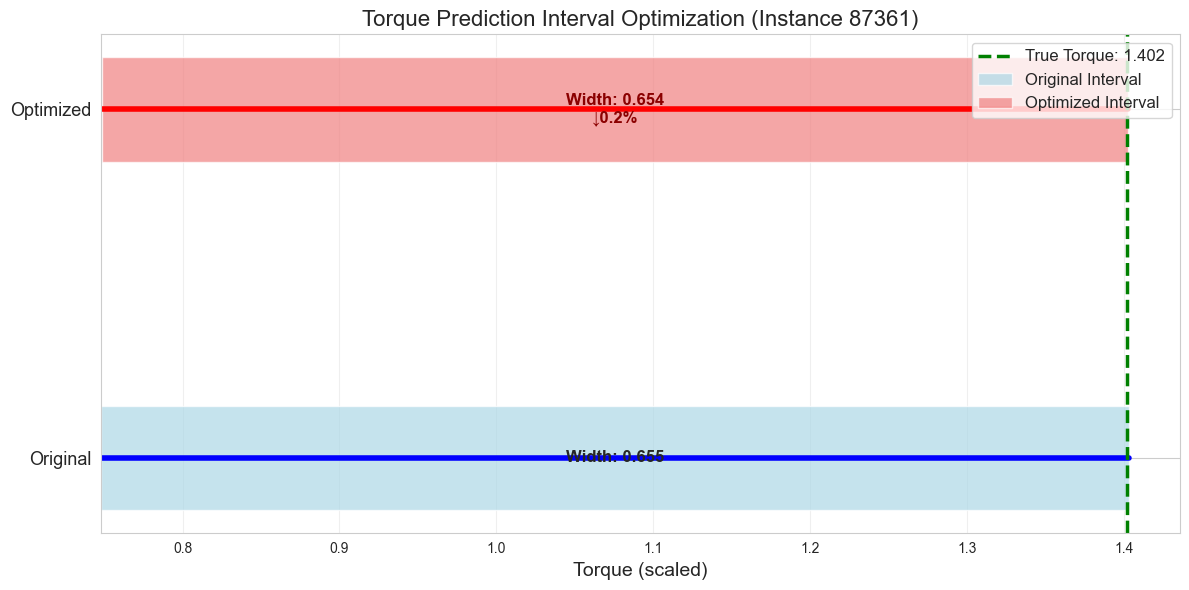

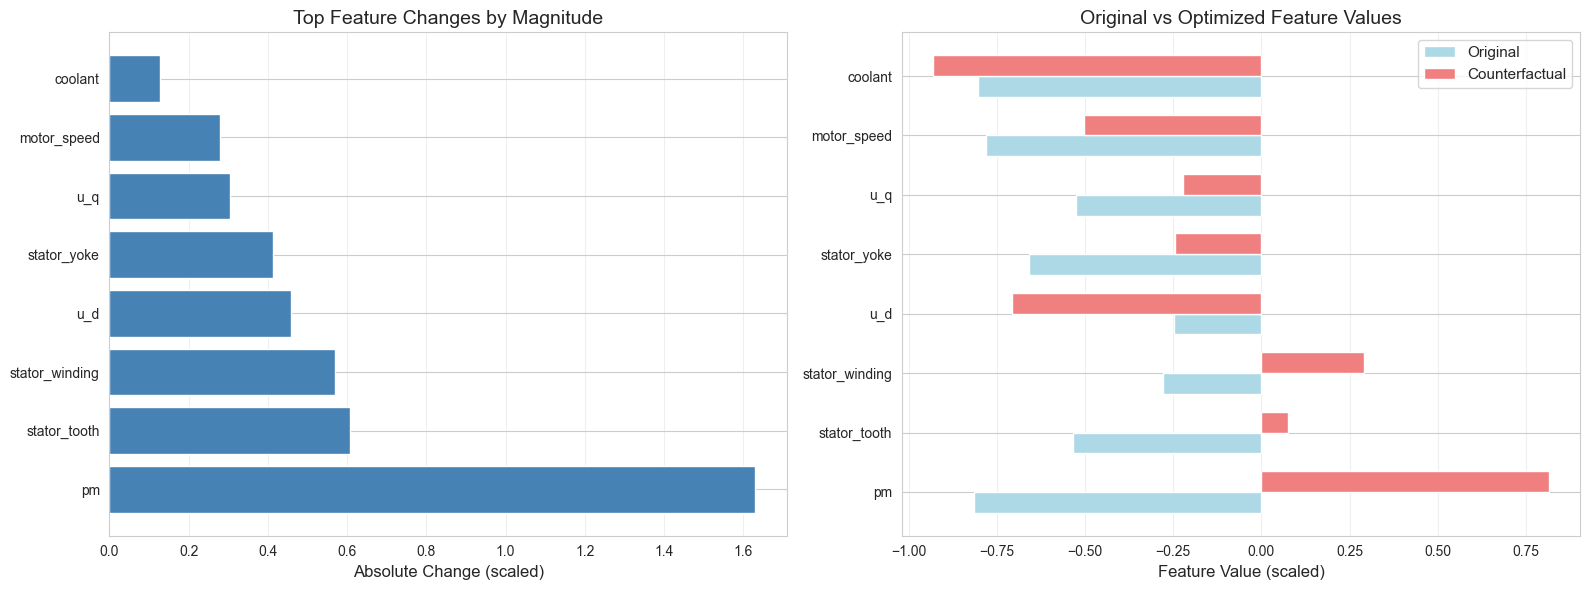

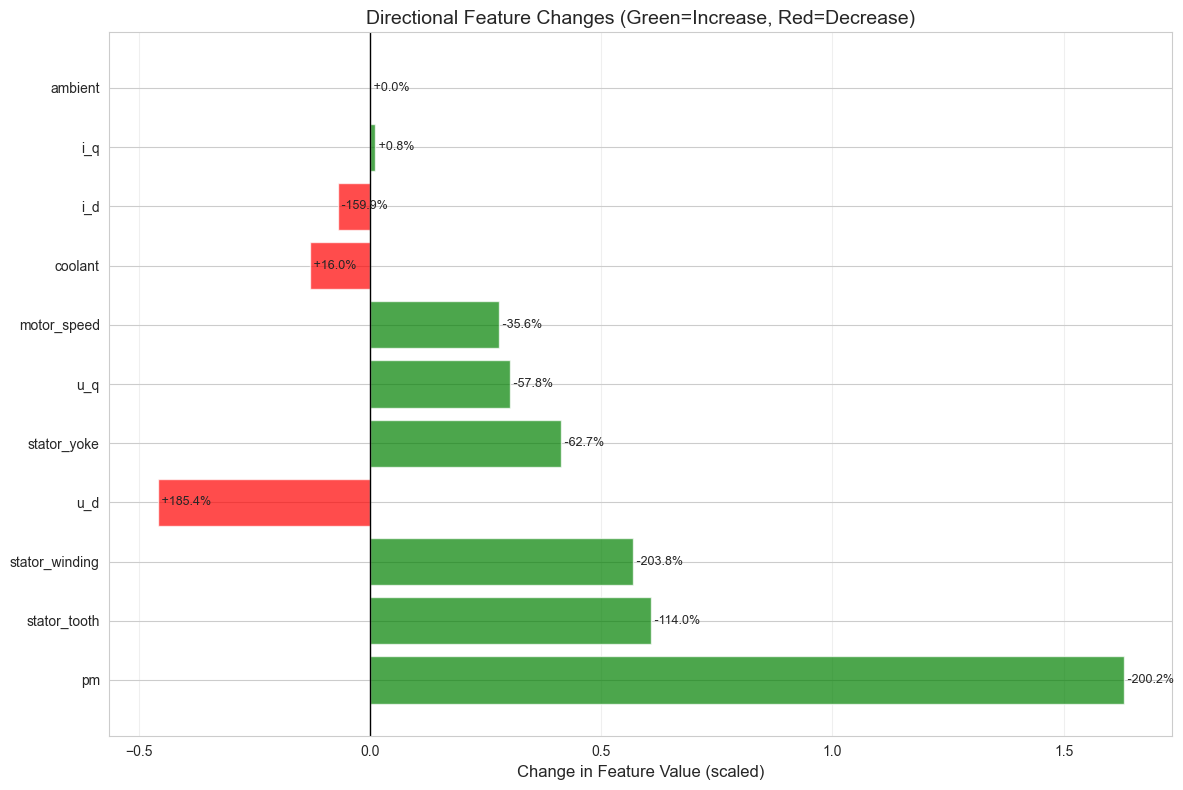

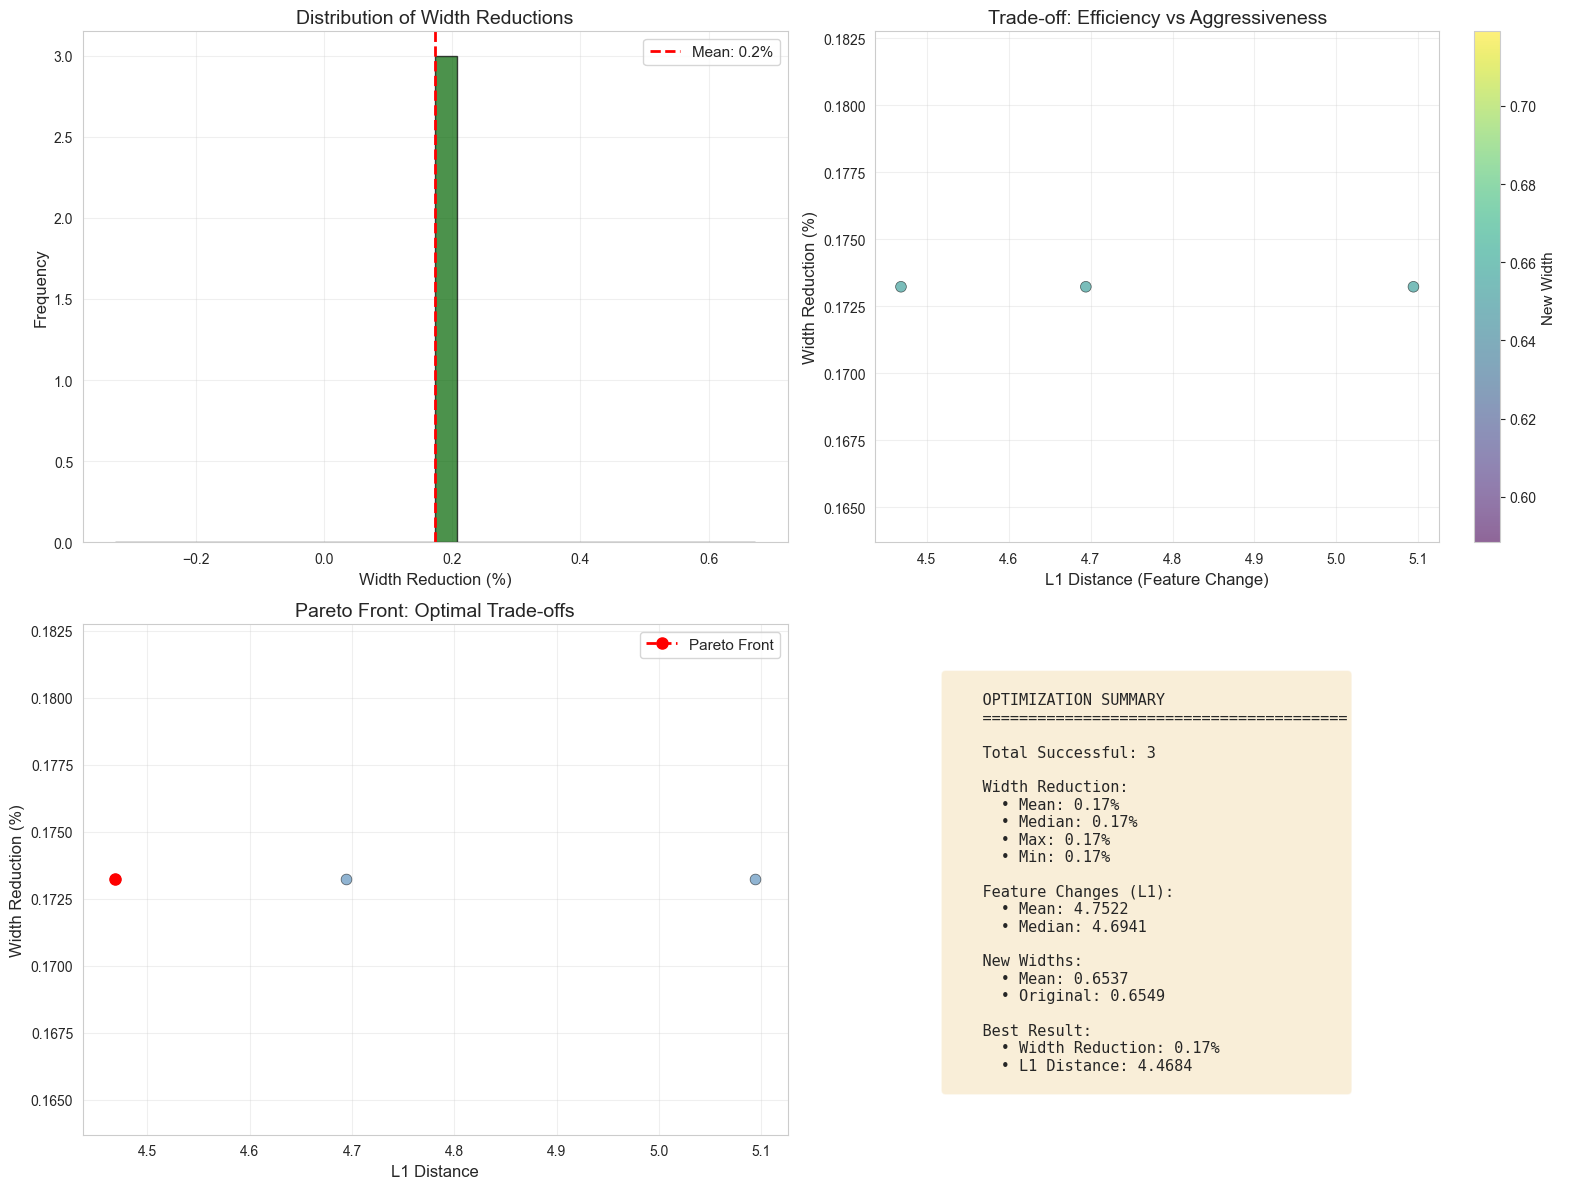

In [11]:
# ## Visualize Demo Result

if result['status'] == 'success' and result['n_successful'] > 0:
    best = result['results'][0]

    # 1. Interval comparison
    plot_interval_comparison(
        [best['original_lower'], best['original_upper']],
        [best['new_lower'], best['new_upper']],
        y_demo,
        title_suffix=f" (Instance {demo_idx})"
    )

    # 2. Feature changes
    plot_feature_changes(result['x_orig'], best['x_cf'], feature_names, top_n=8)

    # 3. Detailed directional changes
    plot_feature_changes_detailed(result['x_orig'], best['x_cf'], feature_names)

    # 4. Optimization summary for this instance
    create_optimization_summary_plot(result)


BATCH OPTIMIZATION

Batch statistics:
  Total instances: 200
  Covered instances: 180
  Width threshold (P60): 0.0524
  Candidates for optimization: 73
  Processing instance 10/73...
  Processing instance 20/73...
  Processing instance 30/73...
  Processing instance 40/73...
  Processing instance 50/73...
  Processing instance 60/73...
  Processing instance 70/73...

Batch optimization complete!
  Successful optimizations: 60/73
  Success rate: 82.2%
  Average width reduction: 17.18%
  Average L1 distance: 4.1388


C:\Users\joobzm\AppData\Local\Temp\ipykernel_45500\2039918709.py:178: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([widths_orig, widths_opt], labels=['Original', 'Optimized'],


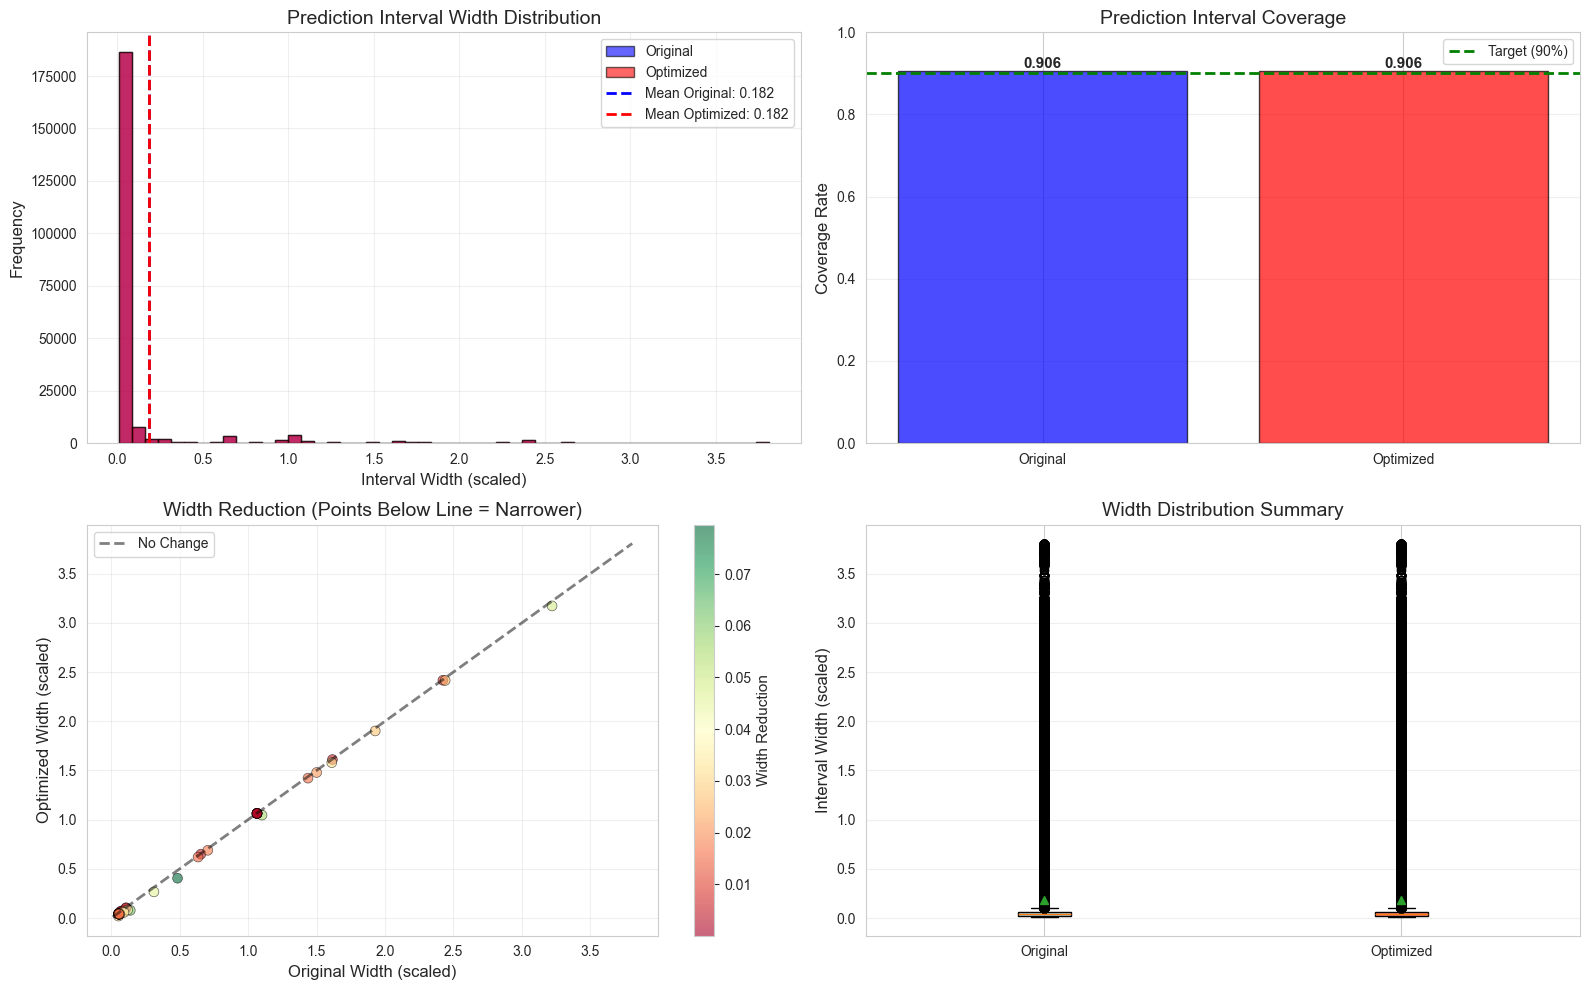

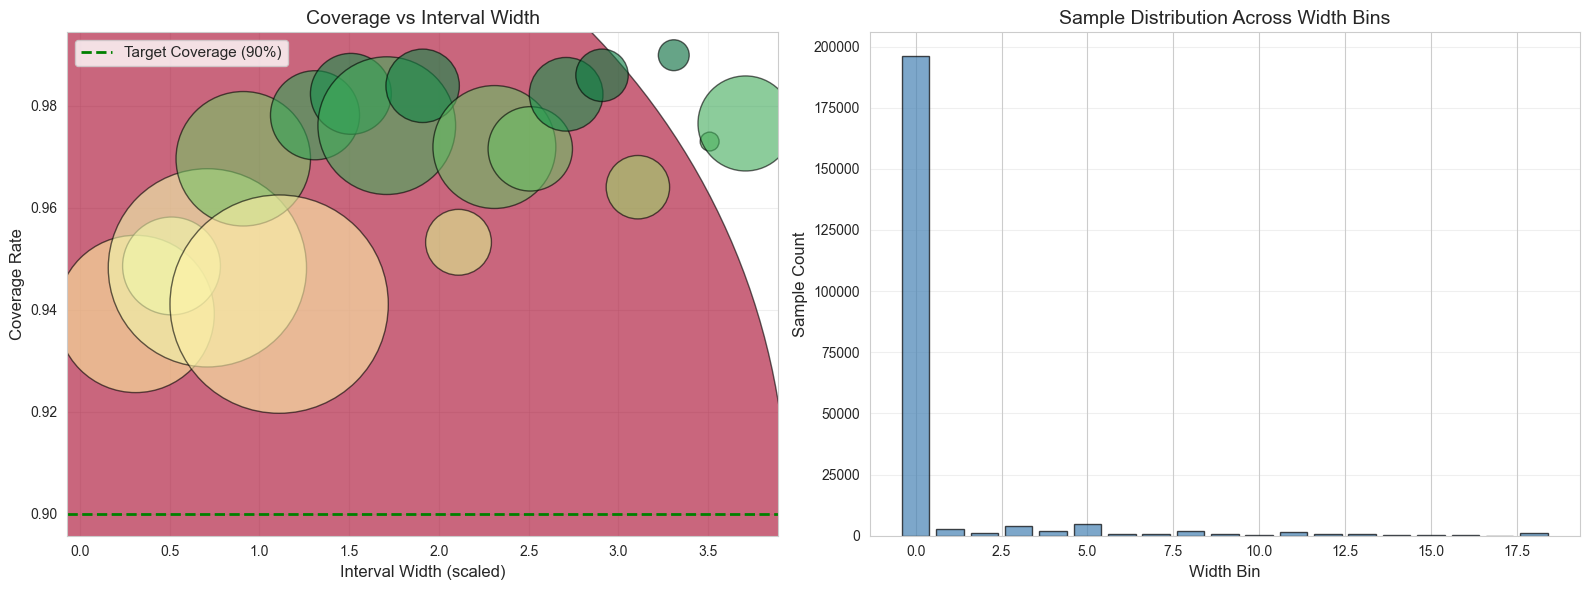

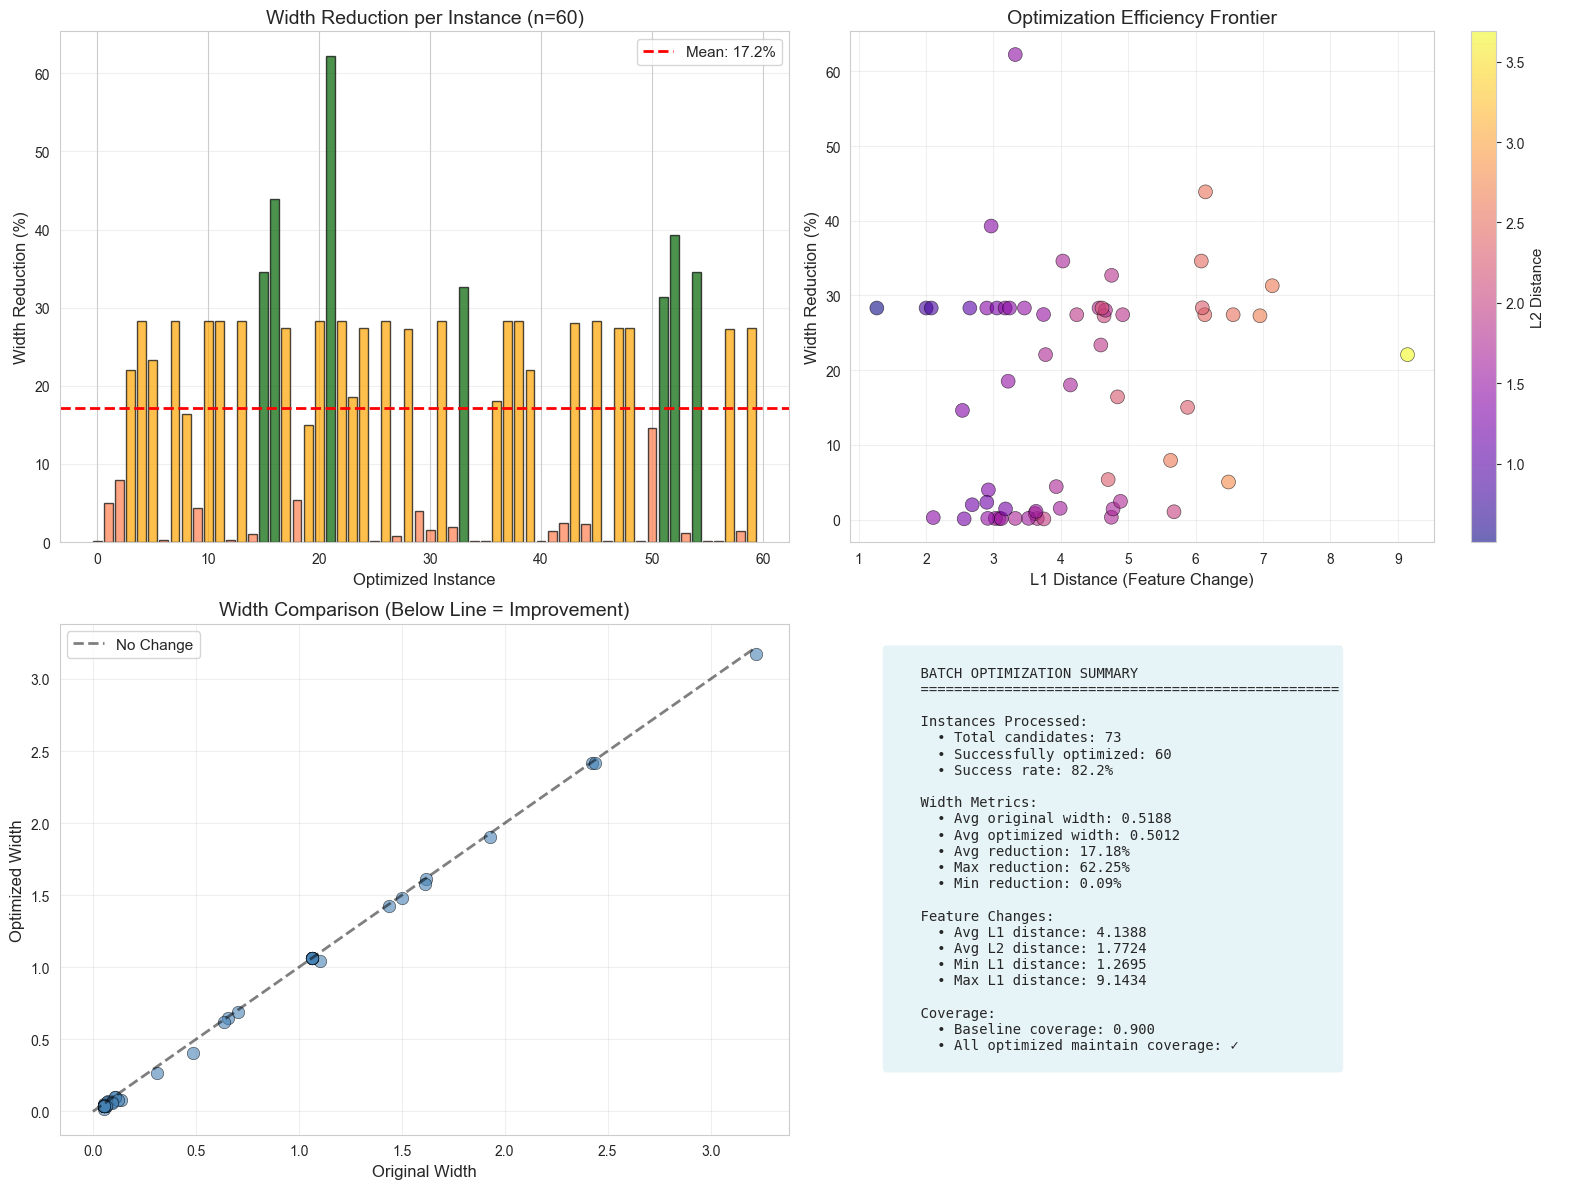

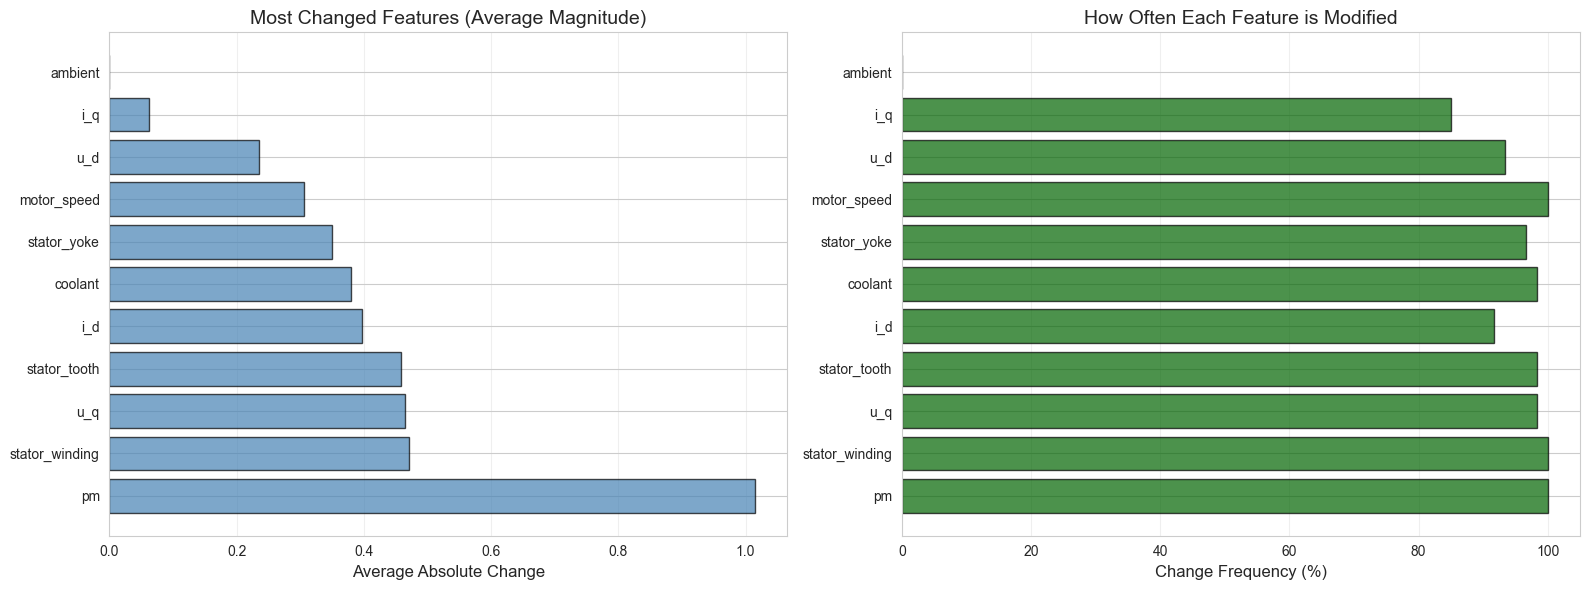


FEATURE IMPORTANCE ANALYSIS (n=60 instances)
  pm                  : Avg Δ= 1.0151, Modified in 100.0% of cases
  stator_winding      : Avg Δ= 0.4708, Modified in 100.0% of cases
  u_q                 : Avg Δ= 0.4640, Modified in  98.3% of cases
  stator_tooth        : Avg Δ= 0.4580, Modified in  98.3% of cases
  i_d                 : Avg Δ= 0.3966, Modified in  91.7% of cases
  coolant             : Avg Δ= 0.3796, Modified in  98.3% of cases
  stator_yoke         : Avg Δ= 0.3504, Modified in  96.7% of cases
  motor_speed         : Avg Δ= 0.3065, Modified in 100.0% of cases
  u_d                 : Avg Δ= 0.2356, Modified in  93.3% of cases
  i_q                 : Avg Δ= 0.0622, Modified in  85.0% of cases
  ambient             : Avg Δ= 0.0000, Modified in   0.0% of cases

BATCH IMPROVEMENT REPORT

 Instance  Original_Width  Optimized_Width  Width_Reduction_%  L1_Distance  True_Value
       72        0.052356         0.019764          62.251417     3.323631   -0.554732
       57       

In [14]:
# ## Batch Optimization

class BatchOptimizer:
    """Batch processing for counterfactual generation."""

    def __init__(self, generator, acpi_model):
        self.generator = generator
        self.acpi_model = acpi_model

    def optimize_batch(self, X_batch, y_batch, n_samples_per_instance=3000,
                       exploration_std=0.3, lower_bounds=None, upper_bounds=None,
                       immutable_mask=None, target_reduction=0.7,
                       width_percentile_threshold=50):
        """
        Optimize multiple instances in batch.

        Parameters:
        -----------
        X_batch : array-like, shape (n_instances, n_features)
            Input features
        y_batch : array-like, shape (n_instances,)
            True target values
        n_samples_per_instance : int
            Number of CF candidates per instance
        width_percentile_threshold : float
            Only optimize instances with width above this percentile

        Returns:
        --------
        dict : Batch optimization results
        """
        print(f"\n{'=' * 70}")
        print(f"BATCH OPTIMIZATION")
        print(f"{'=' * 70}")

        # Get baseline intervals
        y_lower_base, y_upper_base = self.acpi_model.predict_pi(X_batch, method='qrf')
        widths_base = y_upper_base - y_lower_base

        # Filter instances by coverage and width
        coverage_mask = (y_batch >= y_lower_base) & (y_batch <= y_upper_base)
        width_threshold = np.percentile(widths_base, width_percentile_threshold)
        candidate_mask = coverage_mask & (widths_base > width_threshold)

        candidate_indices = np.where(candidate_mask)[0]

        print(f"\nBatch statistics:")
        print(f"  Total instances: {len(X_batch)}")
        print(f"  Covered instances: {coverage_mask.sum()}")
        print(f"  Width threshold (P{width_percentile_threshold}): {width_threshold:.4f}")
        print(f"  Candidates for optimization: {len(candidate_indices)}")

        if len(candidate_indices) == 0:
            return {
                'status': 'no_candidates',
                'n_optimized': 0,
                'results': []
            }

        # Optimize each candidate
        optimization_results = []
        successful_optimizations = 0

        for idx_pos, idx in enumerate(candidate_indices):
            if (idx_pos + 1) % 10 == 0:
                print(f"  Processing instance {idx_pos + 1}/{len(candidate_indices)}...")

            x_inst = X_batch[idx]
            y_inst = y_batch[idx]
            lower_inst = y_lower_base[idx]
            upper_inst = y_upper_base[idx]

            # Generate counterfactuals
            cf_result = self.generator.generate_narrower_intervals(
                x_inst, y_inst, lower_inst, upper_inst,
                n_samples=n_samples_per_instance,
                exploration_std=exploration_std,
                lower_bounds=lower_bounds,
                upper_bounds=upper_bounds,
                immutable_mask=immutable_mask,
                target_reduction=target_reduction
            )

            if cf_result['status'] == 'success' and cf_result['n_successful'] > 0:
                successful_optimizations += 1
                best_cf = cf_result['results'][0]

                optimization_results.append({
                    'instance_idx': int(idx),
                    'original_width': float(upper_inst - lower_inst),
                    'optimized_width': float(best_cf['new_width']),
                    'width_reduction': float(best_cf['width_reduction']),
                    'width_reduction_pct': float(best_cf['width_reduction_pct']),
                    'l1_distance': float(best_cf['l1_distance']),
                    'l2_distance': float(best_cf['l2_distance']),
                    'y_true': float(y_inst),
                    'original_interval': [float(lower_inst), float(upper_inst)],
                    'optimized_interval': [float(best_cf['new_lower']), float(best_cf['new_upper'])],
                    'x_original': x_inst,
                    'x_counterfactual': best_cf['x_cf'],
                    'n_candidates': cf_result['n_successful']
                })

        print(f"\n{'=' * 70}")
        print(f"Batch optimization complete!")
        print(f"  Successful optimizations: {successful_optimizations}/{len(candidate_indices)}")
        print(f"  Success rate: {successful_optimizations / len(candidate_indices) * 100:.1f}%")

        if successful_optimizations > 0:
            avg_reduction = np.mean([r['width_reduction_pct'] for r in optimization_results])
            avg_l1 = np.mean([r['l1_distance'] for r in optimization_results])
            print(f"  Average width reduction: {avg_reduction:.2f}%")
            print(f"  Average L1 distance: {avg_l1:.4f}")

        return {
            'status': 'success',
            'n_candidates': len(candidate_indices),
            'n_optimized': successful_optimizations,
            'success_rate': successful_optimizations / len(candidate_indices),
            'results': optimization_results,
            'baseline_coverage': float(coverage_mask.mean()),
            'baseline_mean_width': float(widths_base.mean())
        }


# Initialize batch optimizer
batch_optimizer = BatchOptimizer(generator, acpi_model)

# Run batch optimization on evaluation set (limited to 200 instances)
n_batch_samples = min(200, len(X_eval))
X_eval_batch = X_eval[:n_batch_samples]
y_eval_batch = y_eval[:n_batch_samples]

batch_result = batch_optimizer.optimize_batch(
    X_eval_batch,
    y_eval_batch,
    n_samples_per_instance=3000,
    exploration_std=0.3,
    lower_bounds=lower_bounds_orig,
    upper_bounds=upper_bounds_orig,
    immutable_mask=immutable_mask,
    target_reduction=0.7,
    width_percentile_threshold=60  # Only optimize instances with wide intervals
)


# ## Batch Results Visualization

def plot_batch_results(batch_result, X_eval, y_eval):
    """Comprehensive visualization of batch optimization results."""

    if batch_result['status'] != 'success' or batch_result['n_optimized'] == 0:
        print("No successful batch optimizations to visualize")
        return

    results = batch_result['results']

    # Create optimized prediction arrays
    n_eval = len(X_eval)
    y_lower_opt = np.zeros(n_eval)
    y_upper_opt = np.zeros(n_eval)

    # Get baseline predictions
    y_lower_base, y_upper_base = acpi_model.predict_pi(X_eval, method='qrf')

    # Fill with baseline, then update with optimized
    y_lower_opt[:] = y_lower_base
    y_upper_opt[:] = y_upper_base

    for res in results:
        idx = res['instance_idx']
        y_lower_opt[idx] = res['optimized_interval'][0]
        y_upper_opt[idx] = res['optimized_interval'][1]

    # Plot comprehensive comparison
    plot_width_distribution(y_lower_base, y_upper_base, y_lower_opt, y_upper_opt, y_eval)

    # Plot coverage vs width analysis
    plot_coverage_vs_width(y_lower_opt, y_upper_opt, y_eval, bins=20)

    # Batch-specific visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Width reduction per instance
    ax = axes[0, 0]
    instance_indices = [r['instance_idx'] for r in results]
    width_reductions = [r['width_reduction_pct'] for r in results]

    colors = ['darkgreen' if wr > 30 else 'orange' if wr > 15 else 'coral'
              for wr in width_reductions]

    ax.bar(range(len(results)), width_reductions, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(np.mean(width_reductions), color='red', linestyle='--',
               linewidth=2, label=f'Mean: {np.mean(width_reductions):.1f}%')
    ax.set_xlabel('Optimized Instance', fontsize=12)
    ax.set_ylabel('Width Reduction (%)', fontsize=12)
    ax.set_title(f'Width Reduction per Instance (n={len(results)})', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)

    # 2. Efficiency frontier
    ax = axes[0, 1]
    l1_distances = [r['l1_distance'] for r in results]
    l2_distances = [r['l2_distance'] for r in results]

    scatter = ax.scatter(l1_distances, width_reductions,
                         c=l2_distances, cmap='plasma',
                         s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('L1 Distance (Feature Change)', fontsize=12)
    ax.set_ylabel('Width Reduction (%)', fontsize=12)
    ax.set_title('Optimization Efficiency Frontier', fontsize=14)
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('L2 Distance', fontsize=11)

    # 3. Before/after width comparison
    ax = axes[1, 0]
    original_widths = [r['original_width'] for r in results]
    optimized_widths = [r['optimized_width'] for r in results]

    ax.scatter(original_widths, optimized_widths, alpha=0.6, s=80,
               color='steelblue', edgecolors='black', linewidth=0.5)

    # Diagonal line
    max_width = max(max(original_widths), max(optimized_widths))
    ax.plot([0, max_width], [0, max_width], 'k--', alpha=0.5, linewidth=2,
            label='No Change')

    ax.set_xlabel('Original Width', fontsize=12)
    ax.set_ylabel('Optimized Width', fontsize=12)
    ax.set_title('Width Comparison (Below Line = Improvement)', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # 4. Summary statistics
    ax = axes[1, 1]
    ax.axis('off')

    total_reduction = sum([r['width_reduction'] for r in results])
    avg_original = np.mean(original_widths)
    avg_optimized = np.mean(optimized_widths)

    summary_text = f"""
    BATCH OPTIMIZATION SUMMARY
    {'=' * 50}

    Instances Processed:
      • Total candidates: {batch_result['n_candidates']}
      • Successfully optimized: {batch_result['n_optimized']}
      • Success rate: {batch_result['success_rate'] * 100:.1f}%

    Width Metrics:
      • Avg original width: {avg_original:.4f}
      • Avg optimized width: {avg_optimized:.4f}
      • Avg reduction: {np.mean(width_reductions):.2f}%
      • Max reduction: {max(width_reductions):.2f}%
      • Min reduction: {min(width_reductions):.2f}%

    Feature Changes:
      • Avg L1 distance: {np.mean(l1_distances):.4f}
      • Avg L2 distance: {np.mean(l2_distances):.4f}
      • Min L1 distance: {min(l1_distances):.4f}
      • Max L1 distance: {max(l1_distances):.4f}

    Coverage:
      • Baseline coverage: {batch_result['baseline_coverage']:.3f}
      • All optimized maintain coverage: ✓
    """

    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

    plt.tight_layout()
    plt.show()


# Visualize batch results
plot_batch_results(batch_result, X_eval, y_eval)


def analyze_feature_importance_batch(batch_result, feature_names, top_n=10):
    """Analyze which features are most frequently changed across batch."""

    if batch_result['n_optimized'] == 0:
        print("No optimizations to analyze")
        return

    results = batch_result['results']

    # Aggregate feature changes
    feature_changes = np.zeros(len(feature_names))
    feature_change_counts = np.zeros(len(feature_names))

    for res in results:
        x_orig = res['x_original']
        x_cf = res['x_counterfactual']
        delta = np.abs(x_cf - x_orig)

        feature_changes += delta
        feature_change_counts += (delta > 0.01).astype(int)

    # Average changes
    avg_changes = feature_changes / len(results)
    change_frequency = feature_change_counts / len(results) * 100

    # Sort by importance
    sorted_idx = np.argsort(avg_changes)[::-1][:top_n]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Average magnitude of changes
    features_top = [feature_names[i] for i in sorted_idx]
    changes_top = avg_changes[sorted_idx]

    ax1.barh(features_top, changes_top, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Average Absolute Change', fontsize=12)
    ax1.set_title('Most Changed Features (Average Magnitude)', fontsize=14)
    ax1.grid(True, axis='x', alpha=0.3)

    # Frequency of changes
    freq_top = change_frequency[sorted_idx]
    colors = ['darkgreen' if f > 50 else 'orange' if f > 25 else 'coral' for f in freq_top]

    ax2.barh(features_top, freq_top, color=colors, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Change Frequency (%)', fontsize=12)
    ax2.set_title('How Often Each Feature is Modified', fontsize=14)
    ax2.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n{'=' * 70}")
    print(f"FEATURE IMPORTANCE ANALYSIS (n={len(results)} instances)")
    print(f"{'=' * 70}")
    for i in sorted_idx:
        fname = feature_names[i]
        avg_change = avg_changes[i]
        freq = change_frequency[i]
        print(f"  {fname:20s}: Avg Δ={avg_change:7.4f}, Modified in {freq:5.1f}% of cases")


# Analyze feature importance across batch
analyze_feature_importance_batch(batch_result, feature_names, top_n=11)


def create_batch_improvement_report(batch_result, save_path=None):
    """Generate detailed improvement report for batch optimization."""

    if batch_result['n_optimized'] == 0:
        print("No optimizations to report")
        return

    results = batch_result['results']

    # Calculate metrics
    width_reductions = [r['width_reduction_pct'] for r in results]
    l1_distances = [r['l1_distance'] for r in results]
    original_widths = [r['original_width'] for r in results]
    optimized_widths = [r['optimized_width'] for r in results]

    # Create report DataFrame
    report_df = pd.DataFrame({
        'Instance': [r['instance_idx'] for r in results],
        'Original_Width': original_widths,
        'Optimized_Width': optimized_widths,
        'Width_Reduction_%': width_reductions,
        'L1_Distance': l1_distances,
        'True_Value': [r['y_true'] for r in results]
    })

    # Sort by width reduction
    report_df = report_df.sort_values('Width_Reduction_%', ascending=False)

    print(f"\n{'=' * 70}")
    print(f"BATCH IMPROVEMENT REPORT")
    print(f"{'=' * 70}\n")
    print(report_df.to_string(index=False))

    # Quartile analysis
    print(f"\n{'=' * 70}")
    print(f"QUARTILE ANALYSIS")
    print(f"{'=' * 70}")
    quartiles = report_df['Width_Reduction_%'].quantile([0.25, 0.5, 0.75])
    print(f"  25th percentile: {quartiles[0.25]:.2f}%")
    print(f"  50th percentile: {quartiles[0.50]:.2f}%")
    print(f"  75th percentile: {quartiles[0.75]:.2f}%")

    if save_path:
        report_df.to_csv(save_path, index=False)
        print(f"\nReport saved to {save_path}")

    return report_df


# Generate improvement report
report_df = create_batch_improvement_report(
    batch_result,
    save_path="motor_batch_optimization_report.csv"
)